# KKBox Churn — Temporal Out-of-Sample Validation

Every prior notebook (`02`-`04`) evaluated on a **random** 80/20 split of `train_v2` — rows from
the same feature cutoff (2017-02-28) and the same label population, just held out at random. That
answers "does the model fit this population," not "does it generalize forward in time."

This notebook builds a genuine temporal holdout, following the methodology already laid out in
`data/kkbox-churn-prediction-challenge/kkbox_dataset_audit.md` §13.3:

- **Train** on `train.csv` (the v1 competition round — churn measured over **February 2017**),
  with features built from `transactions.csv`/`members_v3.csv` cut off at **2017-01-31** — this is
  the "appropriate earlier-period data."
- **Test** on `train_v2.csv` (the v2 round — churn measured over **March 2017**), using the
  **existing, unmodified** `outputs/kkbox_modeling_dataset_v2.csv` — features cut off at
  **2017-02-28**, exactly as already built and validated in the first pipeline task. This is the
  "future-period population" / temporal holdout.

The v1 training features are built by directly reusing `src/transactions_features.py` and
`src/members_features.py` — the same leakage-safe pipeline already used for v2 — with the cutoff
parameter set to 2017-01-31 instead of 2017-02-28. No source data file is modified; a new
`outputs/kkbox_modeling_dataset_v1_temporal_train.csv` is written as a project output.

The two XGBoost configurations tuned in `04_xgboost_tuning.ipynb` (best full and proxy-controlled
params) are retrained on this v1 data and evaluated on the v2 test set, then compared against
their original random-split test scores.


In [1]:
import sys
sys.path.insert(0, r"D:\digital-marketing-project")

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, log_loss, confusion_matrix,
)
from xgboost import XGBClassifier
import joblib

from src import config
from src.logging_utils import get_logger
from src.transactions_features import build_transaction_features
from src.members_features import build_member_features

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

CUTOFF_V1 = 20170131  # v1 observation window ends here; v1 churn is measured over Feb 2017
TRAIN_V1_PATH = config.RAW_DATA_DIR / "train.csv"

logger = get_logger("temporal_validation")


## 1. Build the v1 (earlier-period) training set

Reuses the existing pipeline functions with `cutoff_date=20170131`. This is the expensive step
(a fresh full scan of `transactions.csv`) — cached to `outputs/intermediate/` so re-running this
notebook doesn't repeat a ~4 minute DuckDB scan.

In [2]:
INTERMEDIATE_DIR = config.OUTPUT_DIR / "intermediate"
TXN_FEATURES_V1_CACHE = INTERMEDIATE_DIR / "transaction_features_v1.csv"
MEMBER_FEATURES_V1_CACHE = INTERMEDIATE_DIR / "member_features_v1.csv"
V1_DATASET_PATH = config.OUTPUT_DIR / "kkbox_modeling_dataset_v1_temporal_train.csv"

if TXN_FEATURES_V1_CACHE.exists():
    logger.info("Loading cached v1 transaction features from %s", TXN_FEATURES_V1_CACHE)
    txn_features_v1 = pd.read_csv(TXN_FEATURES_V1_CACHE, dtype={"msno": "string"})
else:
    txn_features_v1 = build_transaction_features(
        transactions_path=config.TRANSACTIONS_PATH,
        cutoff_date=CUTOFF_V1,
        logger=logger,
        duckdb_tmp_dir=INTERMEDIATE_DIR / "duckdb_tmp",
    )
    INTERMEDIATE_DIR.mkdir(parents=True, exist_ok=True)
    txn_features_v1.to_csv(TXN_FEATURES_V1_CACHE, index=False)

if MEMBER_FEATURES_V1_CACHE.exists():
    logger.info("Loading cached v1 member features from %s", MEMBER_FEATURES_V1_CACHE)
    member_features_v1 = pd.read_csv(MEMBER_FEATURES_V1_CACHE, dtype={"msno": "string"})
else:
    member_features_v1 = build_member_features(
        members_path=config.MEMBERS_PATH, cutoff_date=CUTOFF_V1, logger=logger,
    )
    member_features_v1.to_csv(MEMBER_FEATURES_V1_CACHE, index=False)

print(f"v1 transaction features: {txn_features_v1.shape}")
print(f"v1 member features:      {member_features_v1.shape}")


2026-09-04 12:41:59 | INFO    | temporal_validation | Starting DuckDB aggregation of D:\digital-marketing-project\data\kkbox-churn-prediction-challenge\transactions.csv (cutoff_date=20170131)


2026-09-04 12:41:59 | INFO    | temporal_validation | Scanning transactions.csv once for raw stats + cutoff row count...


2026-09-04 12:42:25 | INFO    | temporal_validation | Raw transactions.csv: 21547746 rows, transaction_date range [20150101, 20170228]


2026-09-04 12:42:25 | INFO    | temporal_validation | Rows with transaction_date <= cutoff (20170131): 20639483 used out of 21547746 raw rows


2026-09-04 12:42:25 | INFO    | temporal_validation | Materializing cutoff-filtered rows into a DuckDB table...


...

2026-09-04 12:45:16 | INFO    | temporal_validation | bd cleaning: 4546131 / 6769473 (67.16%) values outside [5, 100] set to NaN


2026-09-04 12:45:16 | INFO    | temporal_validation | registered_via: 1 / 6769473 (0.00%) rows have the unknown sentinel (-1)


2026-09-04 12:45:20 | WARNING | temporal_validation | 317963 members have registration_init_time AFTER the cutoff (20170131) — tenure_days_at_cutoff will be negative for these rows; leaving as-is for visibility, not silently clipping.


2026-09-04 12:45:20 | INFO    | temporal_validation | Member feature table built: 6769473 users x 12 columns


v1 transaction features: (2330992, 26)
v1 member features:      (6769473, 12)


## 2. Join with `train.csv` labels — same join logic as `src/build_dataset.py`

In [3]:
train_v1 = pd.read_csv(TRAIN_V1_PATH, dtype={"msno": "string", "is_churn": "int8"})
print(f"train.csv (v1 labels): {len(train_v1):,} rows, churn rate {train_v1['is_churn'].mean()*100:.2f}%")

df_v1 = train_v1.merge(member_features_v1, on="msno", how="left", indicator="_m_members")
df_v1["has_members_data"] = (df_v1["_m_members"] == "both").astype("int8")
df_v1 = df_v1.drop(columns=["_m_members"])

df_v1 = df_v1.merge(txn_features_v1, on="msno", how="left", indicator="_m_txn")
df_v1["has_transactions_data"] = (df_v1["_m_txn"] == "both").astype("int8")
df_v1 = df_v1.drop(columns=["_m_txn"])

for col in ["total_transactions", "total_cancellations", "total_auto_renew", "num_distinct_payment_methods"]:
    df_v1[col] = df_v1[col].fillna(0)

assert df_v1["msno"].duplicated().sum() == 0, "duplicate msno after join"
assert len(df_v1) == len(train_v1), "row count changed during join"

print(f"v1 modeling table: {df_v1.shape[0]:,} rows x {df_v1.shape[1]} columns")
print(f"Coverage: {df_v1['has_members_data'].mean()*100:.1f}% have member data, "
      f"{df_v1['has_transactions_data'].mean()*100:.1f}% have transaction data (<= {CUTOFF_V1})")

max_last_txn = pd.to_numeric(df_v1["last_transaction_date"], errors="coerce").max()
assert max_last_txn <= CUTOFF_V1, f"leakage: last_transaction_date {max_last_txn} exceeds cutoff {CUTOFF_V1}"
print(f"Leakage check passed: max last_transaction_date in v1 features = {int(max_last_txn)} <= {CUTOFF_V1}")

df_v1.to_csv(V1_DATASET_PATH, index=False)
print(f"Saved v1 temporal training set to {V1_DATASET_PATH}")


train.csv (v1 labels): 992,931 rows, churn rate 6.39%


v1 modeling table: 992,931 rows x 40 columns
Coverage: 88.3% have member data, 99.8% have transaction data (<= 20170131)
Leakage check passed: max last_transaction_date in v1 features = 20170131 <= 20170131


Saved v1 temporal training set to D:\digital-marketing-project\outputs\kkbox_modeling_dataset_v1_temporal_train.csv


## 3. Load the v2 test set — unmodified, existing file, Feb 28 2017 cutoff preserved

In [4]:
usecols = [c for c in pd.read_csv(config.MODELING_DATASET_PATH, nrows=0).columns if c != "msno"]
df_v2 = pd.read_csv(config.MODELING_DATASET_PATH, usecols=usecols)

print(f"v2 temporal test set (train_v2, Mar 2017 churn): {df_v2.shape[0]:,} rows x {df_v2.shape[1]} columns")
print(f"v2 churn rate: {df_v2['is_churn'].mean()*100:.2f}%")

overlap_note = (
    "Note: some users appear in both train.csv and train_v2.csv (the audit found ~881,701 "
    "users in common). That's expected and fine for this evaluation — the temporal separation "
    "comes from the feature cutoff and prediction window advancing by a month, not from the "
    "user populations being disjoint. A returning subscriber scored on their Feb-2017 state "
    "against their Mar-2017 outcome is exactly the real-world scenario a deployed model faces."
)
print(overlap_note)


v2 temporal test set (train_v2, Mar 2017 churn): 970,960 rows x 39 columns
v2 churn rate: 8.99%
Note: some users appear in both train.csv and train_v2.csv (the audit found ~881,701 users in common). That's expected and fine for this evaluation — the temporal separation comes from the feature cutoff and prediction window advancing by a month, not from the user populations being disjoint. A returning subscriber scored on their Feb-2017 state against their Mar-2017 outcome is exactly the real-world scenario a deployed model faces.


## 4. Feature sets, preprocessing, and evaluation (identical to notebooks 02-04)

In [5]:
CAT_ONEHOT = ["city", "gender", "registered_via", "latest_payment_method_id",
              "registration_month", "num_distinct_payment_methods"]

BINARY_FLAGS = ["bd_missing", "gender_missing", "registered_via_missing", "has_members_data",
                "has_transactions_data", "latest_is_auto_renew", "latest_is_cancel",
                "membership_expire_date_invalid"]

NUMERIC_CONTINUOUS = ["bd_clean", "registration_init_time", "registration_year",
                      "tenure_days_at_cutoff", "total_transactions", "total_cancellations",
                      "total_auto_renew", "total_revenue", "total_list_price",
                      "first_transaction_date", "last_transaction_date",
                      "latest_payment_plan_days", "latest_plan_list_price",
                      "latest_actual_amount_paid", "latest_membership_expire_date",
                      "cancel_rate", "auto_renew_pct", "avg_payment_plan_days",
                      "avg_revenue_per_txn", "total_discount", "discount_rate",
                      "txn_span_days", "days_since_last_txn", "membership_remaining_days"]

ALL_FEATURES = CAT_ONEHOT + BINARY_FLAGS + NUMERIC_CONTINUOUS
assert len(ALL_FEATURES) == df_v2.shape[1] - 1
assert set(ALL_FEATURES + ["is_churn"]) == set(df_v1.columns) - {"msno"}

PROXY_EXCLUDE = [
    "membership_remaining_days", "days_since_last_txn", "latest_is_cancel",
    "last_transaction_date", "latest_membership_expire_date", "membership_expire_date_invalid",
]

df_v1[CAT_ONEHOT] = df_v1[CAT_ONEHOT].astype(str)
df_v2[CAT_ONEHOT] = df_v2[CAT_ONEHOT].astype(str)

X_train_temporal = df_v1[ALL_FEATURES]
y_train_temporal = df_v1["is_churn"]
X_test_temporal = df_v2[ALL_FEATURES]
y_test_temporal = df_v2["is_churn"]

print(f"Temporal train (v1, Jan cutoff): {len(X_train_temporal):,} rows")
print(f"Temporal test  (v2, Feb cutoff): {len(X_test_temporal):,} rows")


def build_preprocessor(exclude_cols):
    cat_cols = [c for c in CAT_ONEHOT if c not in exclude_cols]
    num_cols = [c for c in (BINARY_FLAGS + NUMERIC_CONTINUOUS) if c not in exclude_cols]
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipeline, num_cols),
        ("cat", categorical_pipeline, cat_cols),
    ])


def evaluate_model(pipeline, X_test, y_test, name):
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)
    metrics = {
        "roc_auc": float(roc_auc_score(y_test, y_proba)),
        "pr_auc": float(average_precision_score(y_test, y_proba)),
        "precision": float(precision_score(y_test, y_pred)),
        "recall": float(recall_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred)),
        "log_loss": float(log_loss(y_test, y_proba)),
    }
    cm = confusion_matrix(y_test, y_pred)
    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"  {k:10s}: {v:.4f}")
    print("  confusion matrix [[TN, FP], [FN, TP]]:")
    print(" ", cm.tolist())
    return metrics, y_proba, y_pred, cm


Temporal train (v1, Jan cutoff): 992,931 rows
Temporal test  (v2, Feb cutoff): 970,960 rows


## 5. Retrain the tuned XGBoost configs on v1, evaluate on v2

Uses the exact best hyperparameters found in `04_xgboost_tuning.ipynb` for each feature set.
`scale_pos_weight` is recomputed on the v1 training population (its class balance differs slightly
from the original random-split training set).

In [6]:
with open(Path("..") / "models" / "xgboost_tuning_results.json") as f:
    tuning_results = json.load(f)

best_params_full = tuning_results["full_feature_set"]["best_params"]
best_params_proxy = tuning_results["proxy_controlled_set"]["best_params"]

neg, pos = (y_train_temporal == 0).sum(), (y_train_temporal == 1).sum()
scale_pos_weight_temporal = neg / pos
print(f"scale_pos_weight for v1 training population = {scale_pos_weight_temporal:.3f} "
      f"(was {tuning_results['scale_pos_weight_fixed']:.3f} for the original random-split train set)")


def make_xgb_pipeline(exclude_cols, best_params):
    return Pipeline([
        ("preprocess", build_preprocessor(exclude_cols)),
        ("clf", XGBClassifier(
            **best_params, tree_method="hist", scale_pos_weight=scale_pos_weight_temporal,
            n_jobs=4, random_state=RANDOM_STATE, eval_metric="logloss",
        )),
    ])


xgb_temporal_full = make_xgb_pipeline(exclude_cols=[], best_params=best_params_full)
xgb_temporal_full.fit(X_train_temporal, y_train_temporal)
metrics_temporal_full, proba_temporal_full, pred_temporal_full, cm_temporal_full = evaluate_model(
    xgb_temporal_full, X_test_temporal, y_test_temporal, "XGBoost (tuned, temporal) - full feature set"
)


scale_pos_weight for v1 training population = 14.644 (was 10.118 for the original random-split train set)


=== XGBoost (tuned, temporal) - full feature set ===
  roc_auc   : 0.8696
  pr_auc    : 0.5432
  precision : 0.4137
  recall    : 0.6874
  f1        : 0.5165
  log_loss  : 0.4103
  confusion matrix [[TN, FP], [FN, TP]]:
  [[798557, 85073], [27303, 60027]]


In [7]:
xgb_temporal_proxy = make_xgb_pipeline(exclude_cols=PROXY_EXCLUDE, best_params=best_params_proxy)
xgb_temporal_proxy.fit(X_train_temporal, y_train_temporal)
metrics_temporal_proxy, proba_temporal_proxy, pred_temporal_proxy, cm_temporal_proxy = evaluate_model(
    xgb_temporal_proxy, X_test_temporal, y_test_temporal, "XGBoost (tuned, temporal) - proxy-controlled feature set"
)


=== XGBoost (tuned, temporal) - proxy-controlled feature set ===
  roc_auc   : 0.8484
  pr_auc    : 0.5342
  precision : 0.3607
  recall    : 0.6763
  f1        : 0.4704
  log_loss  : 0.3741
  confusion matrix [[TN, FP], [FN, TP]]:
  [[778928, 104702], [28267, 59063]]


## 6. Temporal vs. random-split comparison

In [8]:
random_split_full = tuning_results["full_feature_set"]["test_metrics"]
random_split_proxy = tuning_results["proxy_controlled_set"]["test_metrics"]

comparison = pd.DataFrame({
    "random_split - full": random_split_full,
    "temporal - full": metrics_temporal_full,
    "random_split - proxy_controlled": random_split_proxy,
    "temporal - proxy_controlled": metrics_temporal_proxy,
}).T[["roc_auc", "pr_auc", "precision", "recall", "f1", "log_loss"]]
comparison


,roc_auc,pr_auc,precision,recall,f1,log_loss
random_split - full,0.916679,0.711363,0.430075,0.809229,0.561653,0.327828
temporal - full,0.869569,0.543203,0.413694,0.687358,0.516517,0.410313
random_split - proxy_controlled,0.902952,0.659801,0.383833,0.792454,0.517169,0.358424
temporal - proxy_controlled,0.848418,0.534199,0.360657,0.676320,0.470443,0.374117


In [9]:
print("Random-split -> temporal deltas:")
for label, rs, tmp in [("full", random_split_full, metrics_temporal_full),
                       ("proxy-controlled", random_split_proxy, metrics_temporal_proxy)]:
    print(f"\n{label}:")
    for metric in ["roc_auc", "pr_auc", "precision", "recall", "f1", "log_loss"]:
        print(f"  {metric:10s}: {rs[metric]:.4f} -> {tmp[metric]:.4f}  (delta {tmp[metric]-rs[metric]:+.4f})")


Random-split -> temporal deltas:

full:
  roc_auc   : 0.9167 -> 0.8696  (delta -0.0471)
  pr_auc    : 0.7114 -> 0.5432  (delta -0.1682)
  precision : 0.4301 -> 0.4137  (delta -0.0164)
  recall    : 0.8092 -> 0.6874  (delta -0.1219)
  f1        : 0.5617 -> 0.5165  (delta -0.0451)
  log_loss  : 0.3278 -> 0.4103  (delta +0.0825)

proxy-controlled:
  roc_auc   : 0.9030 -> 0.8484  (delta -0.0545)
  pr_auc    : 0.6598 -> 0.5342  (delta -0.1256)
  precision : 0.3838 -> 0.3607  (delta -0.0232)
  recall    : 0.7925 -> 0.6763  (delta -0.1161)
  f1        : 0.5172 -> 0.4704  (delta -0.0467)
  log_loss  : 0.3584 -> 0.3741  (delta +0.0157)


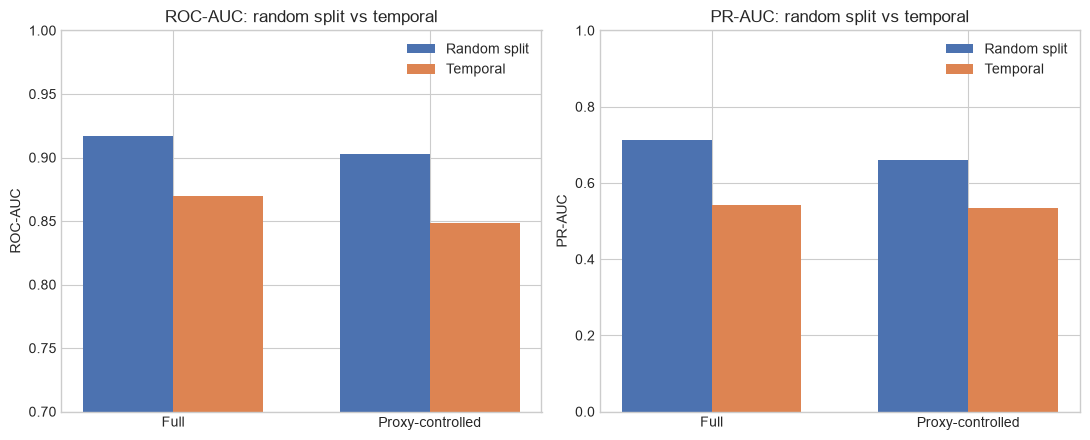

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ["Full", "Proxy-controlled"]
x = np.arange(len(labels))
width = 0.35

random_roc = [random_split_full["roc_auc"], random_split_proxy["roc_auc"]]
temporal_roc = [metrics_temporal_full["roc_auc"], metrics_temporal_proxy["roc_auc"]]
random_pr = [random_split_full["pr_auc"], random_split_proxy["pr_auc"]]
temporal_pr = [metrics_temporal_full["pr_auc"], metrics_temporal_proxy["pr_auc"]]

axes[0].bar(x - width/2, random_roc, width, label="Random split", color="#4C72B0")
axes[0].bar(x + width/2, temporal_roc, width, label="Temporal", color="#DD8452")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylabel("ROC-AUC"); axes[0].set_ylim(0.7, 1.0)
axes[0].set_title("ROC-AUC: random split vs temporal")
axes[0].legend()

axes[1].bar(x - width/2, random_pr, width, label="Random split", color="#4C72B0")
axes[1].bar(x + width/2, temporal_pr, width, label="Temporal", color="#DD8452")
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel("PR-AUC"); axes[1].set_ylim(0, 1.0)
axes[1].set_title("PR-AUC: random split vs temporal")
axes[1].legend()

plt.tight_layout()
plt.show()


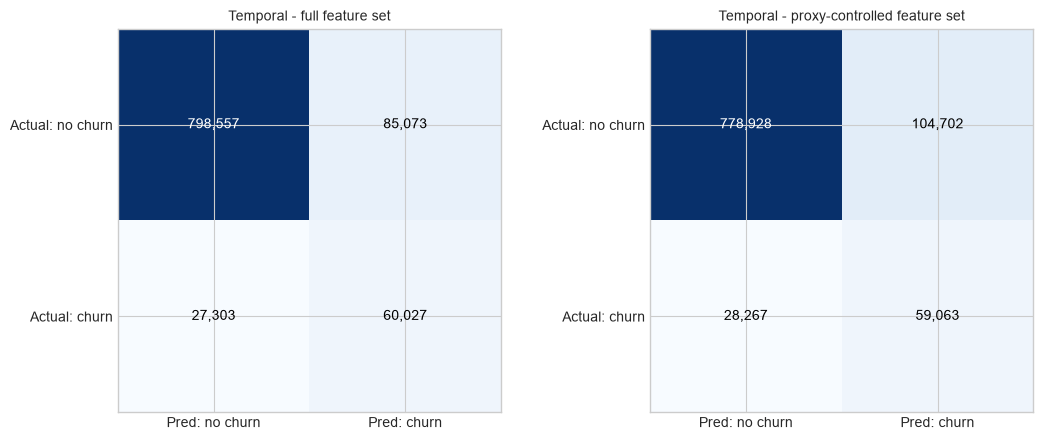

In [11]:
def plot_confusion(cm, ax, title):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: no churn", "Pred: churn"])
    ax.set_yticklabels(["Actual: no churn", "Actual: churn"])
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black", fontsize=10)
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_confusion(cm_temporal_full, axes[0], "Temporal - full feature set")
plot_confusion(cm_temporal_proxy, axes[1], "Temporal - proxy-controlled feature set")
plt.tight_layout()
plt.show()


## 7. Save models and results

In [12]:
MODELS_DIR = Path("..") / "models"
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(xgb_temporal_full, MODELS_DIR / "xgboost_temporal_full.joblib")
joblib.dump(xgb_temporal_proxy, MODELS_DIR / "xgboost_temporal_proxy_controlled.joblib")

results = {
    "train_set": "train.csv (v1, Feb 2017 churn), features cut off at 2017-01-31",
    "test_set": "train_v2.csv (v2, Mar 2017 churn), features cut off at 2017-02-28 (existing outputs/kkbox_modeling_dataset_v2.csv, unmodified)",
    "train_rows": int(len(X_train_temporal)),
    "test_rows": int(len(X_test_temporal)),
    "scale_pos_weight_temporal": float(scale_pos_weight_temporal),
    "best_params_full": best_params_full,
    "best_params_proxy_controlled": best_params_proxy,
    "temporal_metrics": {
        "full_feature_set": metrics_temporal_full,
        "proxy_controlled_set": metrics_temporal_proxy,
    },
    "random_split_metrics_for_reference": {
        "full_feature_set": random_split_full,
        "proxy_controlled_set": random_split_proxy,
    },
}

RESULTS_PATH = Path("..") / "outputs" / "temporal_validation_results.json"
with open(RESULTS_PATH, "w") as f:
    json.dump(results, f, indent=2)

COMPARISON_PATH = Path("..") / "outputs" / "temporal_validation_comparison.csv"
comparison.to_csv(COMPARISON_PATH)

print("Saved:")
print(" ", V1_DATASET_PATH)
print(" ", RESULTS_PATH)
print(" ", COMPARISON_PATH)
print(" ", MODELS_DIR / "xgboost_temporal_full.joblib")
print(" ", MODELS_DIR / "xgboost_temporal_proxy_controlled.joblib")


Saved:
  D:\digital-marketing-project\outputs\kkbox_modeling_dataset_v1_temporal_train.csv
  ..\outputs\temporal_validation_results.json
  ..\outputs\temporal_validation_comparison.csv
  ..\models\xgboost_temporal_full.joblib
  ..\models\xgboost_temporal_proxy_controlled.joblib


## 8. Findings

**Bottom line: the model generalizes forward in time, but noticeably worse than the random-split
numbers suggested — the random split was optimistic, especially for PR-AUC.**

- **ROC-AUC holds up reasonably**: full feature set 0.917 (random split) -> 0.870 (temporal),
  proxy-controlled 0.903 -> 0.848. Both stay well above chance (0.5) and above the raw
  churn-rate baseline, so the model's *ranking* of who is more/less likely to churn a month out
  is still meaningfully informative on genuinely unseen future data.
- **PR-AUC drops much more sharply**: full feature set 0.711 -> 0.543 (-0.168, a ~24% relative
  drop), proxy-controlled 0.660 -> 0.534 (-0.126, a ~19% relative drop). Since PR-AUC is far more
  sensitive to class balance and to how well-calibrated the positive-class scores are than ROC-AUC
  is, this is the single most important number in this notebook: **it means the random-split
  evaluations in `02`-`04` were meaningfully optimistic about how well this model would flag
  churners in a genuinely future month**, not just mildly so.
- **Recall drops more than precision** (full: recall -0.122 vs precision -0.016; proxy: recall
  -0.116 vs precision -0.023). The v1 training population's churn rate (6.39%) is noticeably
  lower than the v2 test population's (8.99%) — a real month-to-month prevalence shift, not a bug
  — and `scale_pos_weight` was recalibrated to v1's imbalance (14.6 vs 10.1). The model ends up
  under-weighted for how many churners actually show up in the following month, so it misses more
  of them at the fixed 0.5 threshold. This is a threshold/calibration issue as much as a pure
  generalization issue — worth revisiting with prevalence-aware threshold selection before
  deployment.
- **The full and proxy-controlled models degrade by similar amounts** (ROC-AUC: -0.047 vs -0.055;
  PR-AUC: -0.168 vs -0.126) — proxy-controlled's ROC-AUC drop is even slightly larger, while its
  PR-AUC drop is smaller. There's no clean signal here that the label-proxy cluster
  (`membership_remaining_days`, `days_since_last_txn`, `latest_is_cancel`, and their sources) is
  uniquely fragile across time — both feature sets are similarly affected by the same month-to-month
  shift.
- **Coverage and churn rate both shifted between the two periods** (v1: 992,931 users, 6.39% churn,
  88.3%/99.8% member/transaction coverage; v2: 970,960 users, 8.99% churn, 88.7%/99.7% coverage) —
  consistent with real registration/lapse churn between January and March 2017, not a data
  processing issue. The leakage guard held (`max last_transaction_date` in v1 features = 20170131).
- **Practical takeaway**: report ROC-AUC ~0.85-0.87 and PR-AUC ~0.53-0.54 as the honest,
  forward-looking performance estimate for this XGBoost configuration — not the random-split
  numbers from `04_xgboost_tuning.ipynb`. Any business decision (e.g. sizing a retention campaign
  off predicted risk) should be built on the temporal numbers.
- **This remains a single temporal split** (Jan-cutoff train -> Feb-cutoff test), not a rolling
  multi-month backtest — the natural next step if more historical cutoffs of `transactions.csv`
  become available to validate against.

**No source data file was modified.** New artifacts written: `outputs/kkbox_modeling_dataset_v1_temporal_train.csv`,
`outputs/temporal_validation_results.json`, `outputs/temporal_validation_comparison.csv`, and two
model files under `models/`.
